In [461]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [462]:
df=pd.read_csv('Blood_Glucose.csv')
df.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0.0,0.0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1.0,0.0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1.0,0.0,N
3,9.0,F,NaN,78.0,High,115.0,96.0,98.300707,NaN,NaN,NaN,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0.0,0.0,N


In [463]:
df.shape

(16969, 12)

In [464]:
df.isnull().sum()
df.duplicated().sum()

np.int64(146)

In [465]:
df.columns

Index(['Age', 'Gender', 'Blood Glucose Reading', 'Diastolic Blood Pressure',
       'Diastolic Blood Pressure Level', 'Systolic Blood Pressure',
       'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)',
       'Shivering (Y/N)', 'Diabetic/NonDiabetic (D/N)'],
      dtype='object')

In [466]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16969 entries, 0 to 16968
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             16969 non-null  float64
 1   Gender                          16877 non-null  object 
 2   Blood Glucose Reading           16121 non-null  float64
 3   Diastolic Blood Pressure        16950 non-null  float64
 4   Diastolic Blood Pressure Level  16950 non-null  object 
 5   Systolic Blood Pressure         16969 non-null  float64
 6   Heart Rate                      16969 non-null  float64
 7   Body Temperature                16735 non-null  float64
 8   SPO2                            16121 non-null  float64
 9   Sweating  (Y/N)                 16121 non-null  float64
 10  Shivering (Y/N)                 16121 non-null  float64
 11  Diabetic/NonDiabetic (D/N)      16969 non-null  object 
dtypes: float64(9), object(3)
memory 

In [467]:
df.describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N)
count,16969.000000,16121.000000,16950.000000,16969.000000,16969.000000,16735.000000,16121.000000,16121.000000,16121.000000
mean,30.982209,95.719219,77.172537,118.183029,91.505045,97.359325,97.380645,0.121493,0.145481
std,29.736598,49.947465,8.414652,8.947304,12.084934,0.814258,0.986455,0.379650,0.409722
min,-122.524773,-162.066433,33.724424,71.984987,29.065509,96.000132,92.287436,-1.838546,-1.970002
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000,0.000000,0.000000
50%,14.000000,83.000000,76.000000,118.000000,89.000000,97.331641,98.000000,0.000000,0.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.953929,98.000000,0.000000,0.000000
max,184.502497,353.498975,120.622562,164.389343,153.982873,98.999792,102.476288,2.081459,2.260927


In [468]:
# Get all duplicate-related rows: original + duplicate copies
dup_cols = df.columns.tolist()

duplicates_all = df[df.duplicated(keep=False)].copy()

# Create duplicate group number
duplicates_all['Duplicate_Group'] = duplicates_all.groupby(
    dup_cols,
    dropna=False
).ngroup() + 1

# Create copy number inside each duplicate group
duplicates_all['Copy_Number'] = duplicates_all.groupby('Duplicate_Group').cumcount() + 1

# Mark first row as Original, others as Duplicate
duplicates_all['Row_Type'] = duplicates_all['Copy_Number'].apply(
    lambda x: 'Original' if x == 1 else 'Duplicate'
)

# Show original index also
duplicates_all = duplicates_all.reset_index(names='Original_Index')

# Sort so original and duplicates come up/down together
duplicates_all = duplicates_all.sort_values(
    by=['Duplicate_Group', 'Copy_Number']
)

duplicates_all

df = df.drop_duplicates().copy()

In [469]:
cat_col=df.select_dtypes(include=['object']).columns
binary_cols = ['Sweating  (Y/N)', 'Shivering (Y/N)']
num_col=df.select_dtypes(include=['int64','float64']).columns
num_col=num_col.drop(binary_cols)
print(f'categorical_features:{cat_col}')
print(f'numerical_features:{num_col}')
print(f'binary_features:{binary_cols}')

categorical_features:Index(['Gender', 'Diastolic Blood Pressure Level',
       'Diabetic/NonDiabetic (D/N)'],
      dtype='object')
numerical_features:Index(['Age', 'Blood Glucose Reading', 'Diastolic Blood Pressure',
       'Systolic Blood Pressure', 'Heart Rate', 'Body Temperature', 'SPO2'],
      dtype='object')
binary_features:['Sweating  (Y/N)', 'Shivering (Y/N)']


In [470]:
df[num_col].describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2
count,16823.000000,15985.000000,16804.000000,16823.000000,16823.000000,16589.000000,15985.000000
mean,31.066285,95.868598,77.129106,118.184082,91.551157,97.358188,97.379630
std,29.772295,50.131380,8.418213,8.969021,12.116773,0.813571,0.989380
min,-122.524773,-162.066433,33.724424,71.984987,29.065509,96.000132,92.287436
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000
50%,14.000000,83.000000,76.000000,119.000000,89.000000,97.330016,98.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.952272,98.000000
max,184.502497,353.498975,120.622562,164.389343,153.982873,98.999792,102.476288


In [471]:
df[num_col].skew()

Age                         0.439018
Blood Glucose Reading       1.543956
Diastolic Blood Pressure    0.130383
Systolic Blood Pressure    -0.170736
Heart Rate                  0.685032
Body Temperature            0.198153
SPO2                       -0.245680
dtype: float64

In [472]:
df[num_col].kurt()

Age                         5.164340
Blood Glucose Reading       8.970250
Diastolic Blood Pressure    5.291065
Systolic Blood Pressure     5.598174
Heart Rate                  6.100873
Body Temperature           -0.975345
SPO2                        5.464580
dtype: float64

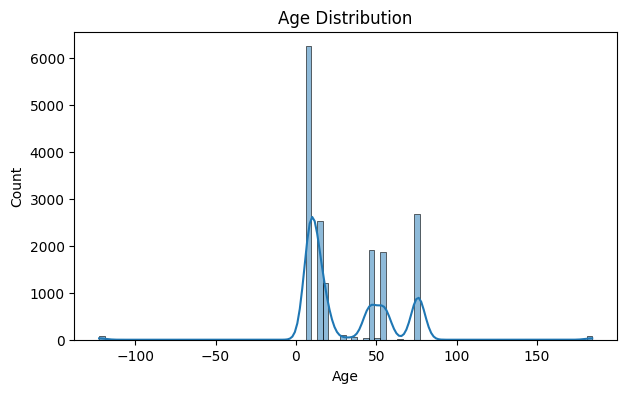

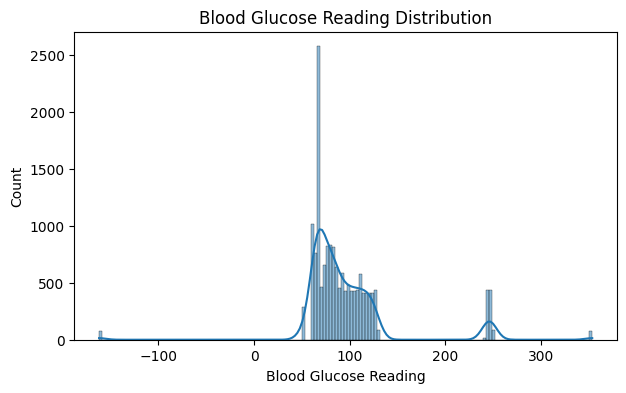

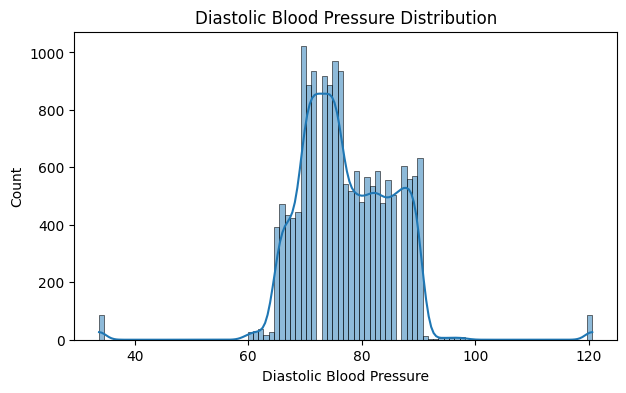

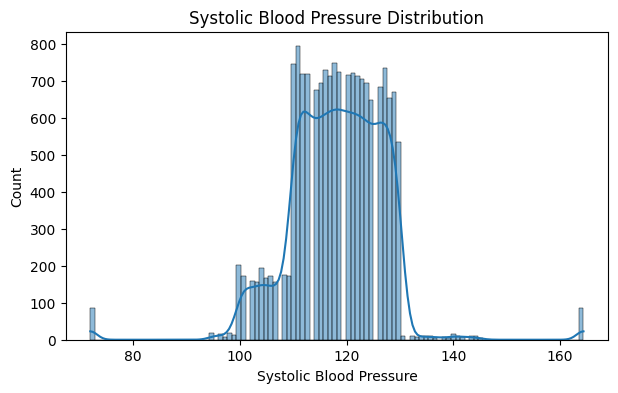

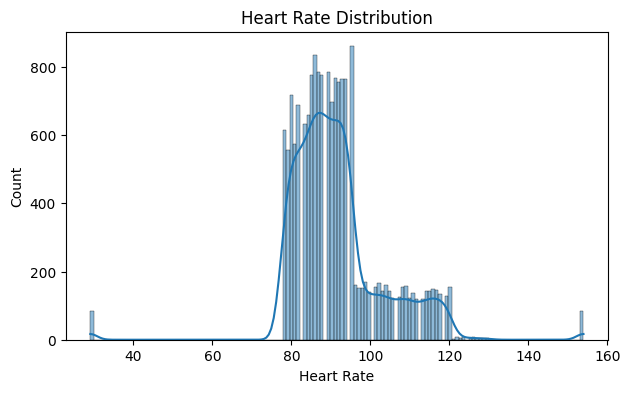

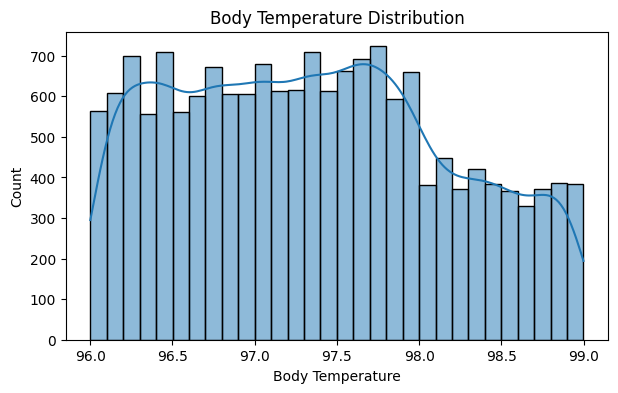

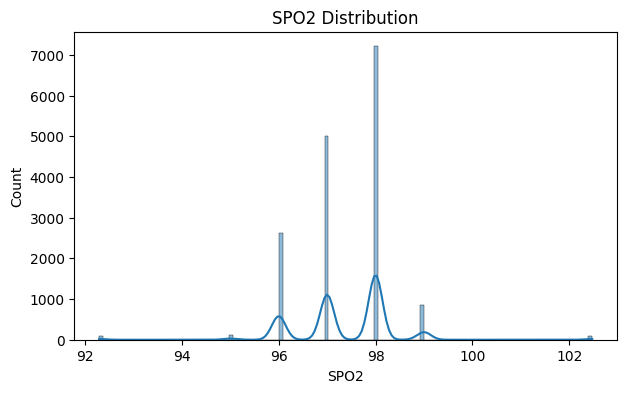

In [473]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_col:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [474]:
df_clean = df.copy()

df_clean = df_clean[
    (df_clean['Age'] >= 0) &
    (df_clean['Age'] <= 100)
]

df_clean = df_clean[
    df_clean['Blood Glucose Reading'] >= 0

]

df_clean = df_clean[
    df_clean['Sweating  (Y/N)'].isin([0, 1]) &
    df_clean['Shivering (Y/N)'].isin([0, 1])
].copy()

df_clean['Sweating  (Y/N)'] = df_clean['Sweating  (Y/N)'].astype(int)
df_clean['Shivering (Y/N)'] = df_clean['Shivering (Y/N)'].astype(int)


print("Before cleaning:")
print("Min SPO2:", df_clean['SPO2'].min())
print("Max SPO2:", df_clean['SPO2'].max())
print("Rows before:", df_clean.shape[0])

invalid_spo2 = df_clean[
    (df_clean['SPO2'] < 0) | 
    (df_clean['SPO2'] > 100)
]
print("Invalid SPO2 count:", invalid_spo2.shape[0])
invalid_spo2[['SPO2']].head()

df_clean = df_clean[
    (df_clean['SPO2'] >= 0) &
    (df_clean['SPO2'] <= 100)
].copy()



Before cleaning:
Min SPO2: 92.28743596975988
Max SPO2: 102.47628836495882
Rows before: 15421
Invalid SPO2 count: 75


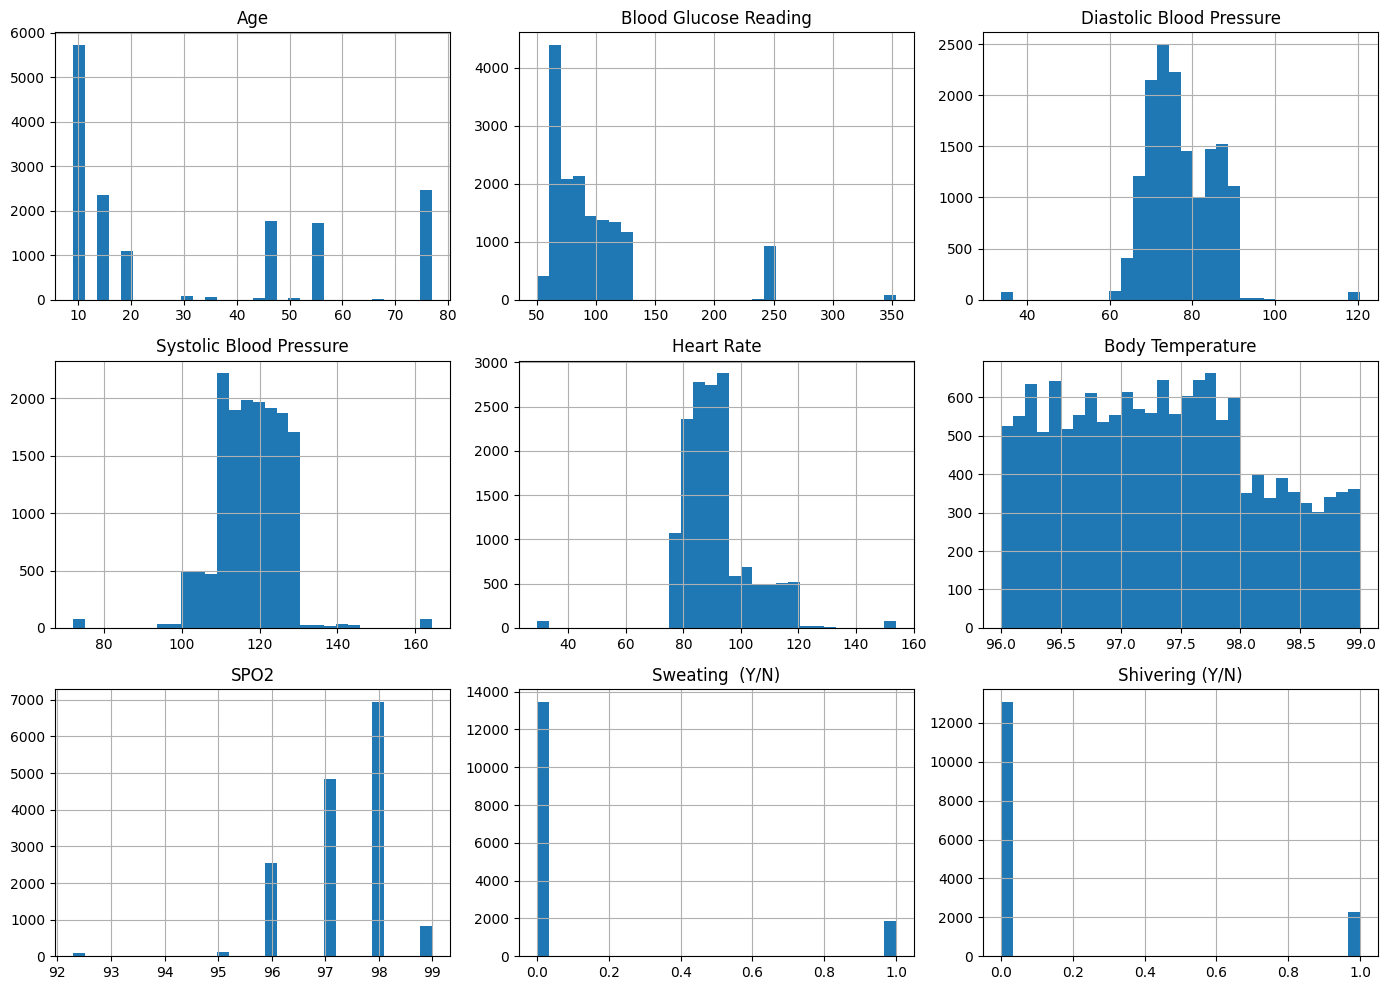

In [475]:
df_clean.hist(
    bins=30,
    figsize=(14, 10),
    grid=True
)

plt.tight_layout()
plt.show()

In [476]:
df_clean['Sweating  (Y/N)'].unique()

array([0, 1])

In [477]:
df_clean['Shivering (Y/N)'].unique()

array([0, 1])

In [478]:
df_clean.dtypes

Age                               float64
Gender                             object
Blood Glucose Reading             float64
Diastolic Blood Pressure          float64
Diastolic Blood Pressure Level     object
Systolic Blood Pressure           float64
Heart Rate                        float64
Body Temperature                  float64
SPO2                              float64
Sweating  (Y/N)                     int64
Shivering (Y/N)                     int64
Diabetic/NonDiabetic (D/N)         object
dtype: object

In [479]:
df_clean.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,N
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,N


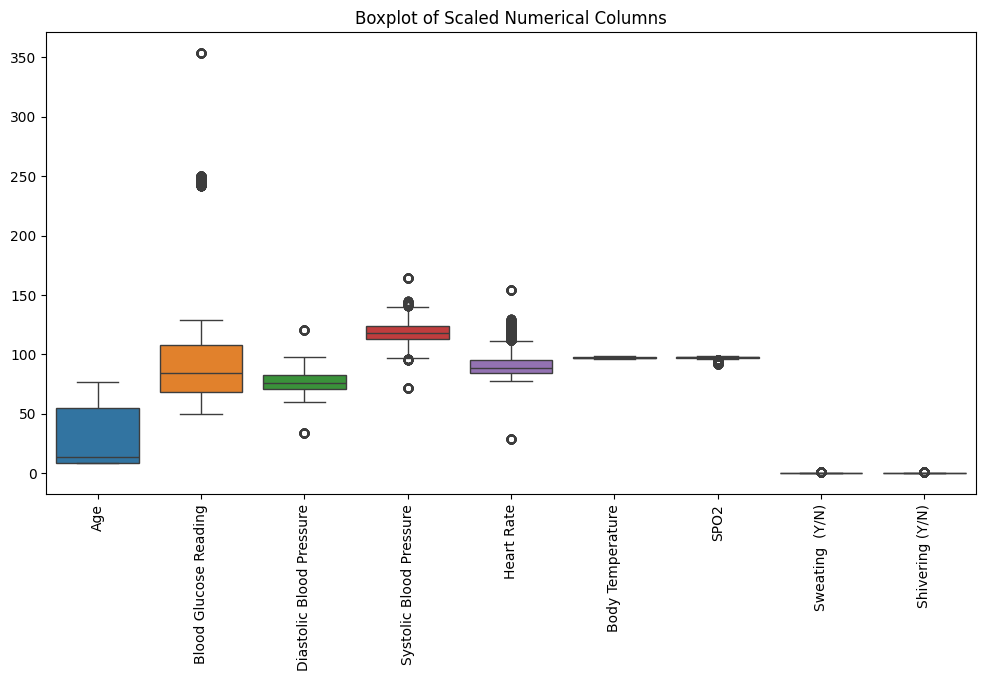

In [480]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean)
plt.title('Boxplot of Scaled Numerical Columns')
plt.xticks(rotation=90)
plt.show()

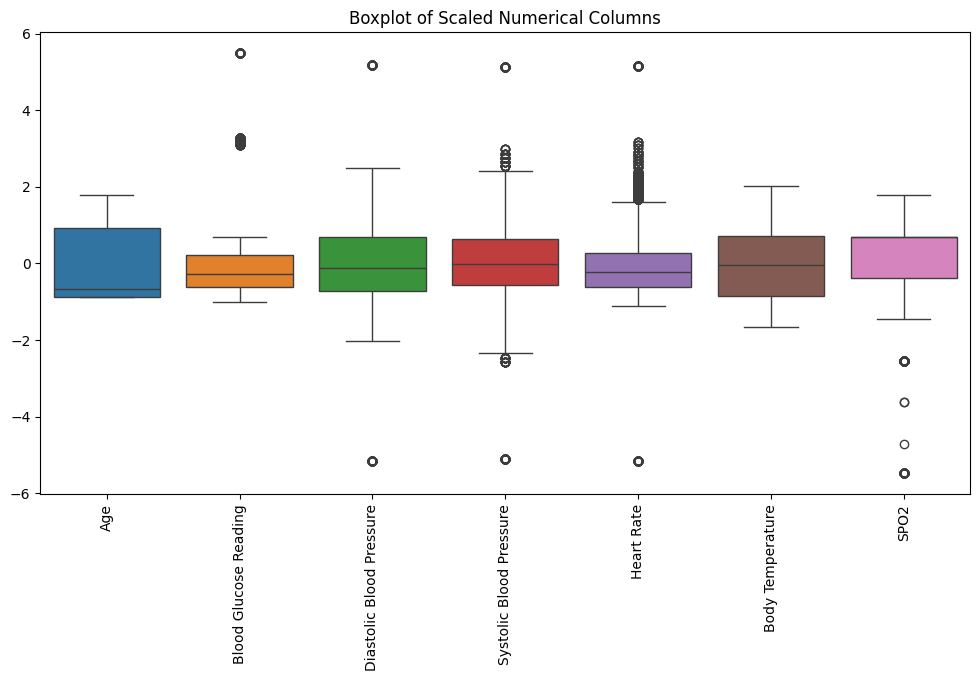

In [481]:
#boxplot 
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled=scaler.fit_transform(df_clean[num_col])
df_clean_scaled=pd.DataFrame(scaled,columns=num_col)

plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean_scaled)
plt.title('Boxplot of Scaled Numerical Columns')
plt.xticks(rotation=90)
plt.show()

0 = average value
negative value = below average
positive value = above average

In [482]:
df_clean.describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N)
count,15346.000000,15346.000000,15328.000000,15346.000000,15346.000000,15137.000000,15346.000000,15346.000000,15346.000000
mean,31.120683,97.159678,77.109877,118.158320,91.613288,97.359128,97.352367,0.122638,0.147335
std,25.589397,46.706995,8.406591,9.019447,12.118856,0.814552,0.924235,0.328032,0.354451
min,9.000000,50.000000,33.724424,71.984987,29.065509,96.000132,92.287436,0.000000,0.000000
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000,0.000000,0.000000
50%,14.000000,84.000000,76.000000,118.000000,89.000000,97.331110,98.000000,0.000000,0.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.951796,98.000000,0.000000,0.000000
max,77.000000,353.498975,120.622562,164.389343,153.982873,98.999792,99.000000,1.000000,1.000000


In [483]:
total_outliers = []

for col in num_col:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    total_outliers.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outliers.shape[0]
    })

iqr_df = pd.DataFrame(total_outliers)

iqr_df

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,9.000000,55.000000,46.000000,-60.000000,124.000000,0
1,Blood Glucose Reading,68.000000,108.000000,40.000000,8.000000,168.000000,1010
2,Diastolic Blood Pressure,71.000000,83.000000,12.000000,53.000000,101.000000,153
3,Systolic Blood Pressure,113.000000,124.000000,11.000000,96.500000,140.500000,230
4,Heart Rate,84.000000,95.000000,11.000000,67.500000,111.500000,1346
5,Body Temperature,96.674465,97.951796,1.277331,94.758469,99.867792,0
6,SPO2,97.000000,98.000000,1.000000,95.500000,99.500000,203


In [484]:
df_clean.describe()

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N)
count,15346.000000,15346.000000,15328.000000,15346.000000,15346.000000,15137.000000,15346.000000,15346.000000,15346.000000
mean,31.120683,97.159678,77.109877,118.158320,91.613288,97.359128,97.352367,0.122638,0.147335
std,25.589397,46.706995,8.406591,9.019447,12.118856,0.814552,0.924235,0.328032,0.354451
min,9.000000,50.000000,33.724424,71.984987,29.065509,96.000132,92.287436,0.000000,0.000000
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000,0.000000,0.000000
50%,14.000000,84.000000,76.000000,118.000000,89.000000,97.331110,98.000000,0.000000,0.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.951796,98.000000,0.000000,0.000000
max,77.000000,353.498975,120.622562,164.389343,153.982873,98.999792,99.000000,1.000000,1.000000


In [485]:
df_clean.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,N
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,N


In [486]:
df_clean.duplicated().sum()

np.int64(0)

In [487]:
df_clean.dtypes

Age                               float64
Gender                             object
Blood Glucose Reading             float64
Diastolic Blood Pressure          float64
Diastolic Blood Pressure Level     object
Systolic Blood Pressure           float64
Heart Rate                        float64
Body Temperature                  float64
SPO2                              float64
Sweating  (Y/N)                     int64
Shivering (Y/N)                     int64
Diabetic/NonDiabetic (D/N)         object
dtype: object

## Categorical features

In [488]:
target = 'Diabetic/NonDiabetic (D/N)'

cat_col = [
    'Gender',
    'Diastolic Blood Pressure Level'
]

binary_cols = [
    'Sweating  (Y/N)',
    'Shivering (Y/N)'
]

all_cat_col = cat_col + binary_cols

print("cat_col:", cat_col)
print("binary_cols:", binary_cols)
print("all_cat_col:", all_cat_col)

cat_col: ['Gender', 'Diastolic Blood Pressure Level']
binary_cols: ['Sweating  (Y/N)', 'Shivering (Y/N)']
all_cat_col: ['Gender', 'Diastolic Blood Pressure Level', 'Sweating  (Y/N)', 'Shivering (Y/N)']


In [489]:
df_clean.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,N
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,N


In [490]:
for col in all_cat_col:
    print(col)
    print(df_clean[col].value_counts())
    print(df_clean[col].value_counts(normalize=True) * 100)
    print("------------------")

Gender
Gender
M    10563
F     4701
Name: count, dtype: int64
Gender
M    69.202044
F    30.797956
Name: proportion, dtype: float64
------------------
Diastolic Blood Pressure Level
Diastolic Blood Pressure Level
High      15246
Low          81
Medium        1
Name: count, dtype: int64
Diastolic Blood Pressure Level
High      99.465031
Low        0.528445
Medium     0.006524
Name: proportion, dtype: float64
------------------
Sweating  (Y/N)
Sweating  (Y/N)
0    13464
1     1882
Name: count, dtype: int64
Sweating  (Y/N)
0    87.736218
1    12.263782
Name: proportion, dtype: float64
------------------
Shivering (Y/N)
Shivering (Y/N)
0    13085
1     2261
Name: count, dtype: int64
Shivering (Y/N)
0    85.266519
1    14.733481
Name: proportion, dtype: float64
------------------


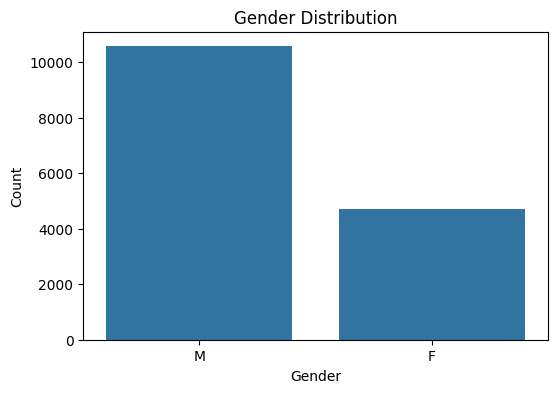

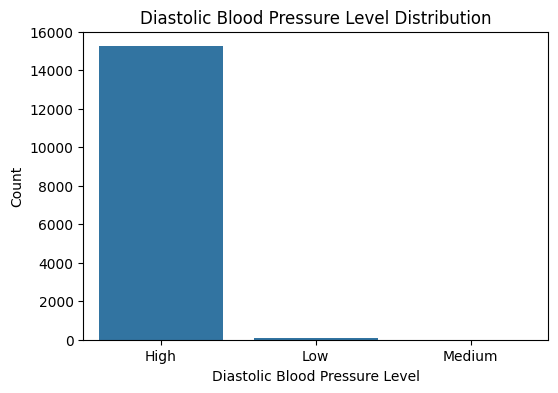

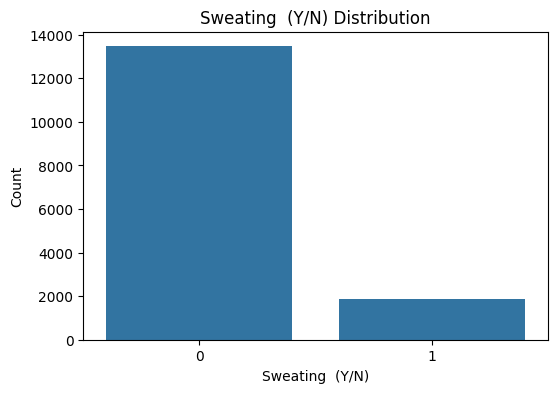

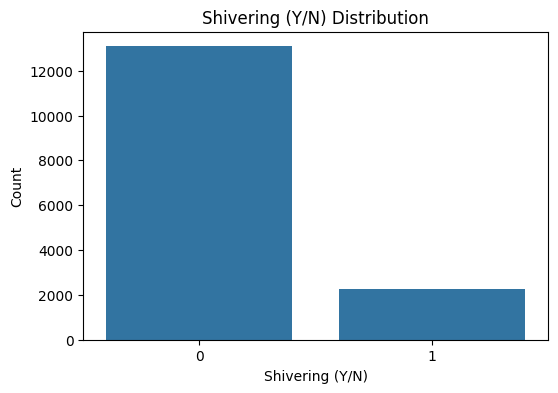

In [491]:

for col in all_cat_col:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df_clean)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

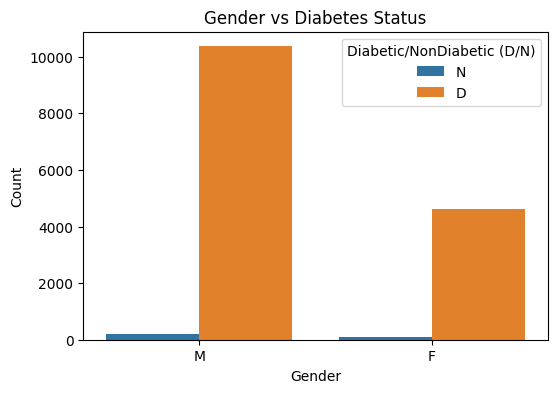

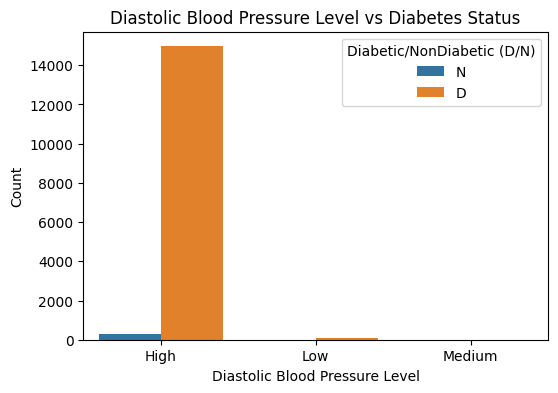

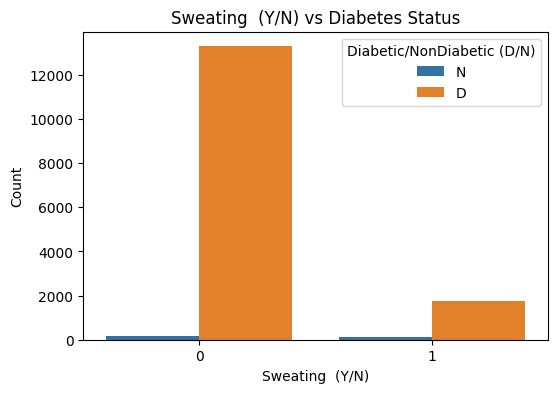

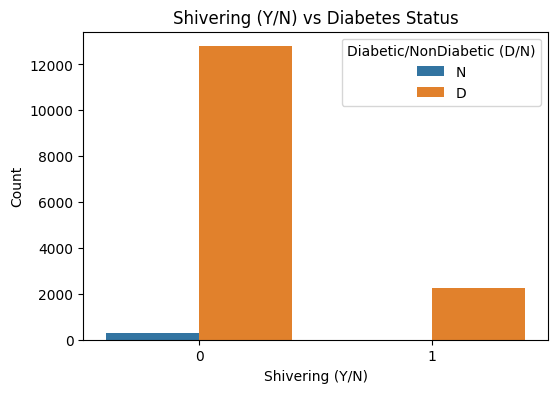

In [492]:
target = 'Diabetic/NonDiabetic (D/N)'

for col in all_cat_col:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue=target, data=df_clean)
    plt.title(f'{col} vs Diabetes Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [493]:
for col in all_cat_col:
    print(col)
    print(pd.crosstab(df_clean[col], df_clean[target]))
    print()
    print(pd.crosstab(df_clean[col], df_clean[target], normalize='index') * 100)
    print("----------------------")

Gender
Diabetic/NonDiabetic (D/N)      D    N
Gender                                
F                            4611   90
M                           10365  198

Diabetic/NonDiabetic (D/N)          D         N
Gender                                         
F                           98.085514  1.914486
M                           98.125533  1.874467
----------------------
Diastolic Blood Pressure Level
Diabetic/NonDiabetic (D/N)          D    N
Diastolic Blood Pressure Level            
High                            14962  284
Low                                72    9
Medium                              0    1

Diabetic/NonDiabetic (D/N)              D           N
Diastolic Blood Pressure Level                       
High                            98.137216    1.862784
Low                             88.888889   11.111111
Medium                           0.000000  100.000000
----------------------
Sweating  (Y/N)
Diabetic/NonDiabetic (D/N)      D    N
Sweating  (Y/N)           

In [494]:
df_clean['Diabetic/NonDiabetic (D/N)'].value_counts()

Diabetic/NonDiabetic (D/N)
D    15048
N      298
Name: count, dtype: int64

In [495]:
df_clean['Diabetic/NonDiabetic (D/N)'].isnull().sum()

np.int64(0)

In [526]:
df_clean.to_csv('df_clean.csv', index=False)
print("Saved df_clean.csv, shape:", df_clean.shape)

Saved df_clean.csv, shape: (15346, 12)


### EDA Insights

EDA insight:
The dataset required cleaning because some columns contained impossible medical values. After cleaning, the dataset became more suitable for analysis and modeling.

D = 15048
N = 298
The target variable is highly imbalanced. Diabetic cases dominate the dataset, while Non-Diabetic cases are very low. This may cause a machine learning model to become biased toward predicting the majority class. Therefore, accuracy alone should not be used for model evaluation.


The numerical features are not perfectly normally distributed. Blood Glucose Reading shows right skewness and high outliers. Several medical features contain extreme values, but because this is medical data, outliers may represent real patient conditions and should not be removed blindly.


IQR analysis showed that Blood Glucose Reading and Heart Rate contain many outliers. However, in medical datasets, outliers do not always mean incorrect values. They may represent abnormal but real patient conditions.


Boxplots showed visible differences in Blood Glucose Reading, Body Temperature, and Blood Pressure between Diabetic and Non-Diabetic groups. However, statistical testing was needed to confirm whether these differences were significant.

In [496]:
df_model = df_clean.copy()

### Features Engineering

In [497]:

df_model['Age_Group'] = pd.cut(df_model['Age'], bins=[0, 18, 40, 60, 100],
                                labels=['Child_Teen', 'Adult', 'Middle_Age', 'Senior'])

df_model['Pulse_Pressure'] = df_model['Systolic Blood Pressure'] - df_model['Diastolic Blood Pressure']

df_model['MAP'] = df_model['Diastolic Blood Pressure'] + (df_model['Pulse_Pressure'] / 3)

df_model['Low_SPO2_Flag'] = (df_model['SPO2'] < 95).astype(int)

df_model['Fever_Flag'] = (df_model['Body Temperature'] > 100.4).astype(int)

df_model['HR_Category'] = pd.cut(df_model['Heart Rate'], bins=[0, 60, 100, 300],   
                                  labels=['Bradycardia', 'Normal', 'Tachycardia'])

df_model['Symptom_Count'] = df_model['Sweating  (Y/N)'] + df_model['Shivering (Y/N)']

In [529]:
df_model.to_csv("df_model.csv", index=False)

print("Saved df_model.csv, shape:", df_model.shape)
print(df_model.columns.tolist())

Saved df_model.csv, shape: (15346, 20)
['Age', 'Gender', 'Blood Glucose Reading', 'Diastolic Blood Pressure', 'Diastolic Blood Pressure Level', 'Systolic Blood Pressure', 'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)', 'Shivering (Y/N)', 'Diabetic/NonDiabetic (D/N)', 'Age_Group', 'Pulse_Pressure', 'MAP', 'Low_SPO2_Flag', 'Fever_Flag', 'HR_Category', 'Symptom_Count', 'Diabetic_Target']


In [498]:
target = 'Diabetic/NonDiabetic (D/N)'

df_model[target] = df_model[target].astype(str).str.strip()

df_model['Diabetic_Target'] = df_model[target].map({
    'N': 0,
    'D': 1
})

df_model[['Diabetic/NonDiabetic (D/N)', 'Diabetic_Target']].head()

df_model['Diabetic_Target'].value_counts()

Diabetic_Target
1    15048
0      298
Name: count, dtype: int64

In [499]:
df_model.head()

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N),Age_Group,Pulse_Pressure,MAP,Low_SPO2_Flag,Fever_Flag,HR_Category,Symptom_Count,Diabetic_Target
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0,0,N,Child_Teen,45.0,88.000000,0,0,Normal,0,0
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1,0,N,Child_Teen,46.0,88.333333,1,0,Tachycardia,1,0
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1,0,N,Child_Teen,34.0,87.333333,0,0,Normal,1,0
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0,0,N,Senior,48.0,112.000000,0,0,Normal,0,0
5,66.0,NaN,100.0,72.0,Low,133.0,89.0,98.351676,96.0,0,0,N,Senior,61.0,92.333333,0,0,Normal,0,0


In [500]:
df_model.dtypes

Age                                float64
Gender                              object
Blood Glucose Reading              float64
Diastolic Blood Pressure           float64
Diastolic Blood Pressure Level      object
Systolic Blood Pressure            float64
Heart Rate                         float64
Body Temperature                   float64
SPO2                               float64
Sweating  (Y/N)                      int64
Shivering (Y/N)                      int64
Diabetic/NonDiabetic (D/N)          object
Age_Group                         category
Pulse_Pressure                     float64
MAP                                float64
Low_SPO2_Flag                        int64
Fever_Flag                           int64
HR_Category                       category
Symptom_Count                        int64
Diabetic_Target                      int64
dtype: object

### Target encoding

In [501]:
target_encoded = 'Diabetic_Target'

num_cols = [
    'Age',
    'Blood Glucose Reading',
    'Diastolic Blood Pressure',
    'Systolic Blood Pressure',
    'Heart Rate',
    'Body Temperature',
    'SPO2',
    'Pulse_Pressure',
    'MAP',
    'Symptom_Count'

]

cat_col = [
    'Gender',
    'Diastolic Blood Pressure Level',
    'Age_Group',
    'HR_Category'
]

binary_cols = [
    'Sweating  (Y/N)',
    'Shivering (Y/N)',
    'Low_SPO2_Flag',
    'Fever_Flag'
]

all_cat_col=cat_col + binary_cols

In [502]:
df_model['Diabetic_Target'].isnull().sum()

np.int64(0)

### Define X and y

In [503]:
X = df_model[num_cols + cat_col + binary_cols]
y = df_model[target_encoded]

In [504]:
y.value_counts()

Diabetic_Target
1    15048
0      298
Name: count, dtype: int64

### Train-test split

In [505]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [506]:
print("Train target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("Test target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train target distribution:
Diabetic_Target
1    98.061258
0     1.938742
Name: proportion, dtype: float64
Test target distribution:
Diabetic_Target
1    98.045603
0     1.954397
Name: proportion, dtype: float64


In [507]:
train_eda = X_train.copy()
train_eda['Diabetic_Target'] = y_train

train_eda['Diabetic_Label'] = train_eda['Diabetic_Target'].map({
    0: 'N',
    1: 'D'
})

train_eda.head()
target_train = 'Diabetic_Label'

In [508]:
print(all_cat_col)

['Gender', 'Diastolic Blood Pressure Level', 'Age_Group', 'HR_Category', 'Sweating  (Y/N)', 'Shivering (Y/N)', 'Low_SPO2_Flag', 'Fever_Flag']


Train data Count plot

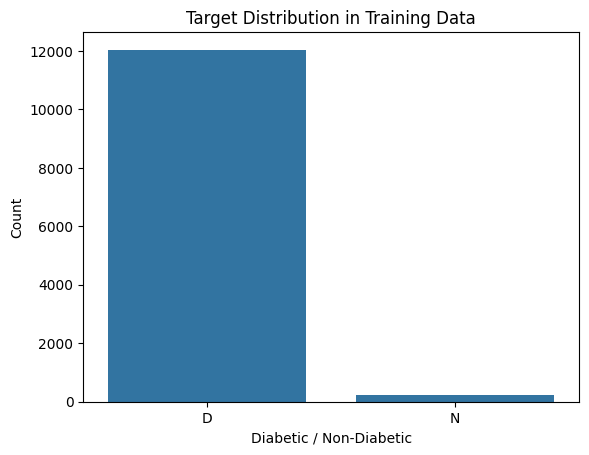

In [509]:

sns.countplot(x=target_train, data=train_eda)

plt.title('Target Distribution in Training Data')
plt.xlabel('Diabetic / Non-Diabetic')
plt.ylabel('Count')
plt.show()

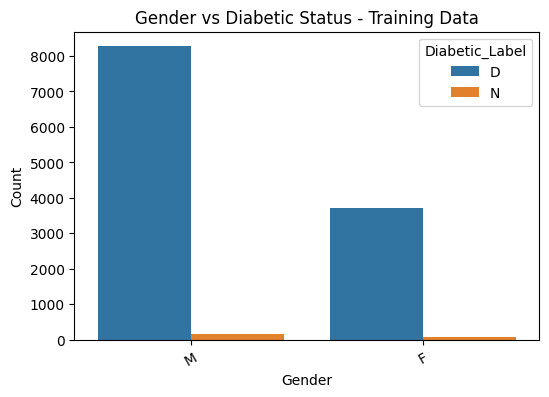

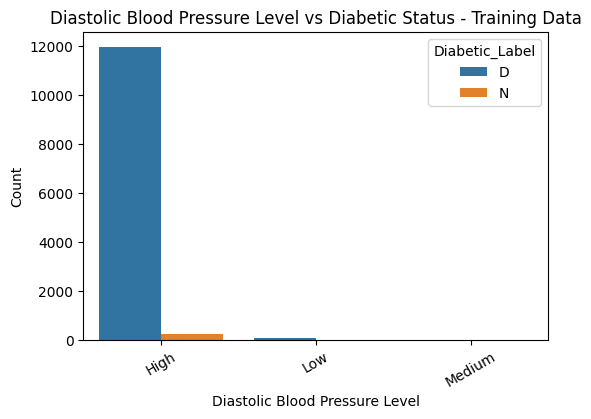

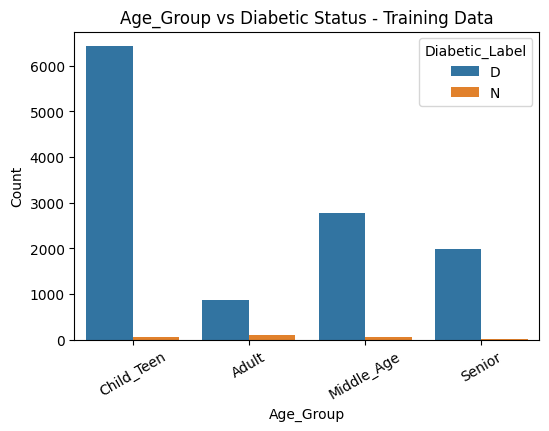

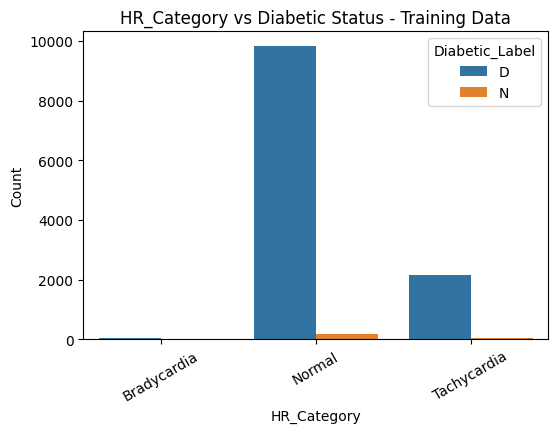

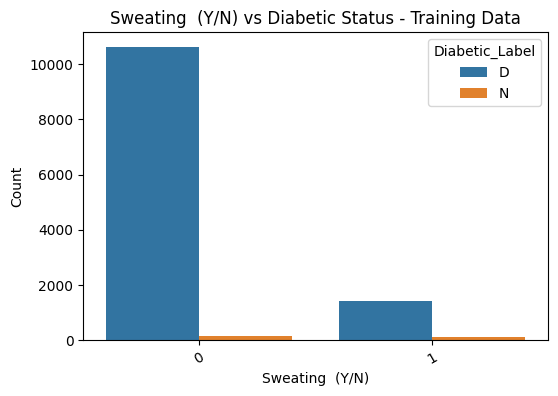

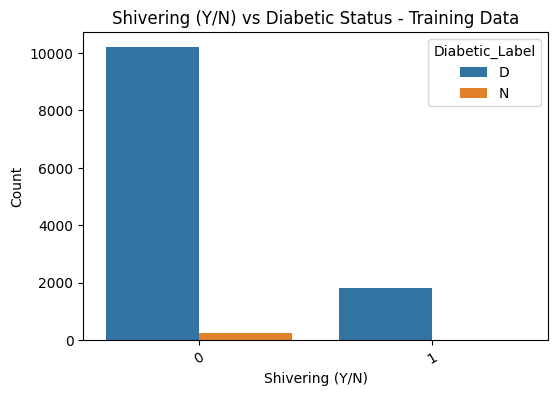

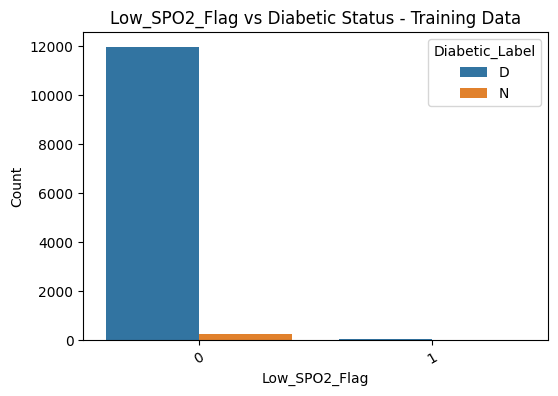

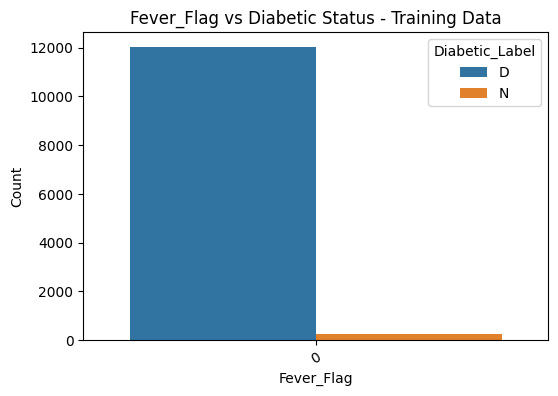

In [510]:
for col in all_cat_col:
    plt.figure(figsize=(6, 4))
    
    sns.countplot(
        x=col,
        hue=target_train,
        data=train_eda
    )
    
    plt.title(f'{col} vs Diabetic Status - Training Data')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=30)
    plt.show()


Training-only Chi-square and Cramer’s V

In [511]:
from scipy.stats import chi2_contingency

chi_results = []

for col in all_cat_col:
    contingency_table = pd.crosstab(train_eda[col], train_eda[target_train])
    
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    
    if min_dim == 0:
        cramers_v = 0
    else:
        cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    chi_results.append({
        'Feature': col,
        'Chi2': chi2,
        'p_value': p_value,
        'Cramers_V': cramers_v,
        'Result': 'Significant' if p_value < 0.05 else 'Not Significant'
    })

chi_results_df = pd.DataFrame(chi_results).sort_values(by='p_value')

chi_results_df

,Feature,Chi2,p_value,Cramers_V,Result
2,Age_Group,513.039293,7.125126e-111,0.204431,Significant
4,Sweating (Y/N),223.068236,1.937062e-50,0.134800,Significant
1,Diastolic Blood Pressure Level,86.958946,1.309498e-19,0.084209,Significant
5,Shivering (Y/N),41.165758,1.398512e-10,0.057908,Significant
0,Gender,0.139459,7.088192e-01,0.003380,Not Significant
6,Low_SPO2_Flag,0.055508,8.137413e-01,0.002126,Not Significant
3,HR_Category,0.030471,9.848802e-01,0.001575,Not Significant
7,Fever_Flag,0.000000,1.000000e+00,0.000000,Not Significant


The Chi-square test shows that Sweating, Diastolic Blood Pressure Level, and Shivering have statistically significant associations with diabetes status. However, Cramer’s V values are low, indicating weak relationship strength. Gender is not statistically significant and has almost no association with diabetes status.



Training-only numerical vs target boxplots

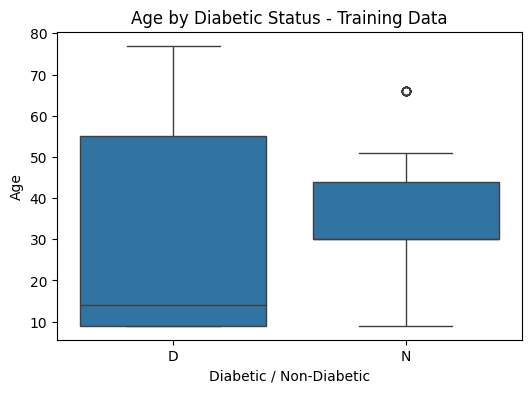

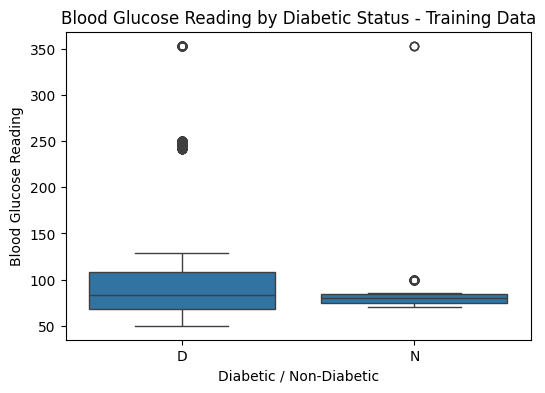

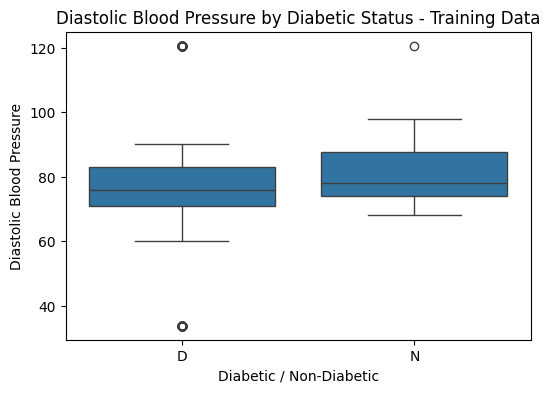

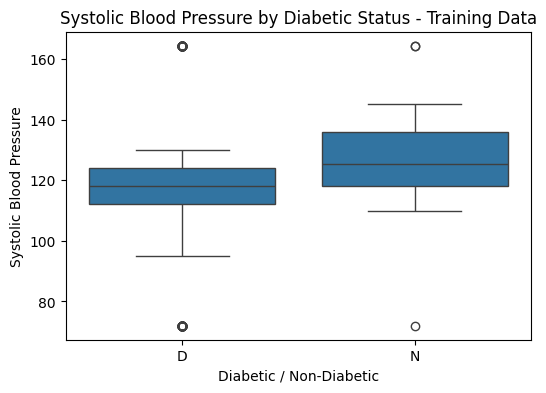

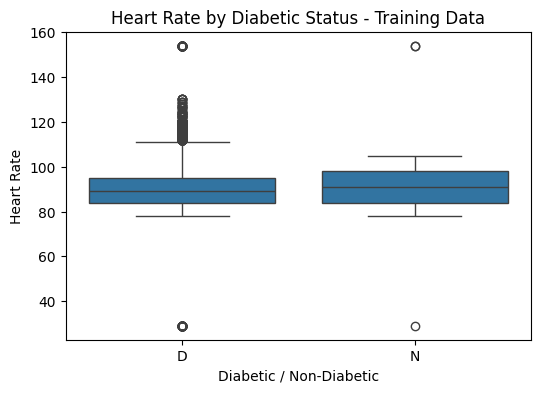

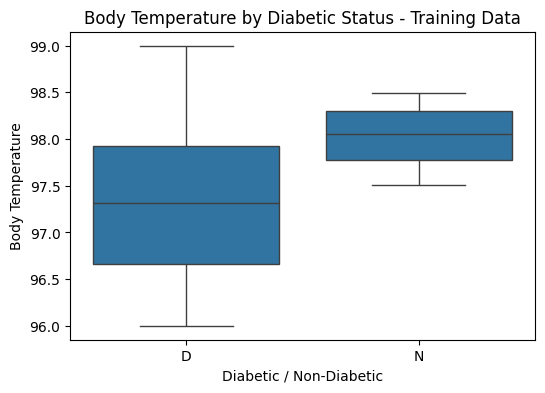

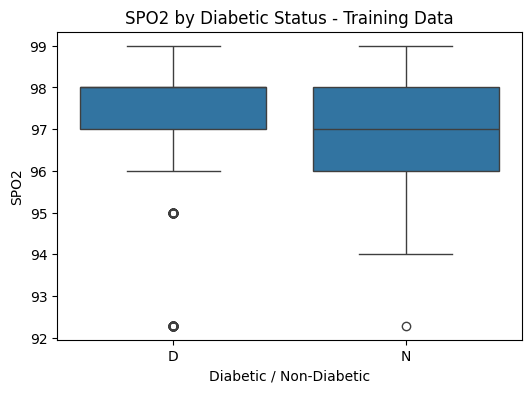

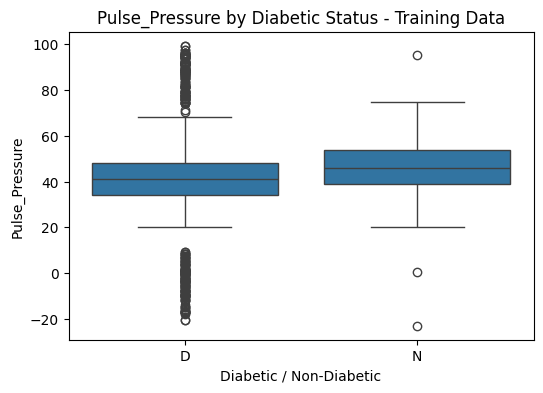

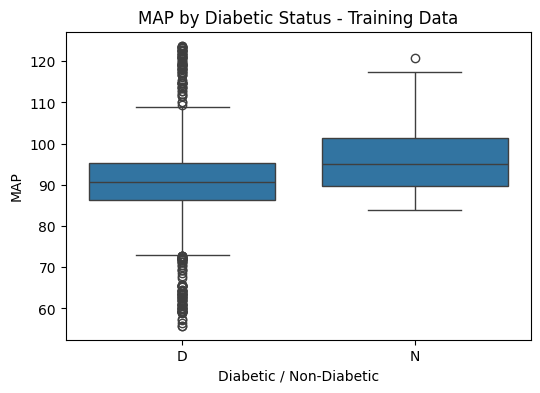

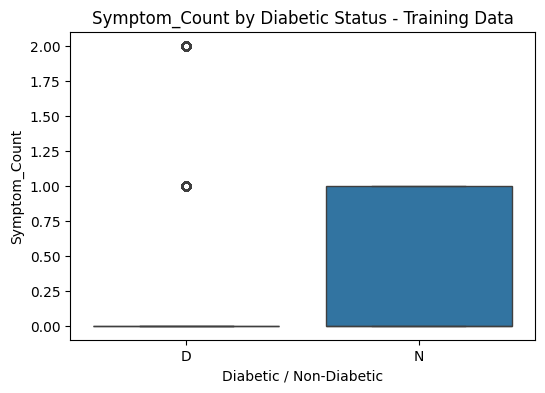

In [512]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(
        x=target_train,
        y=col,
        data=train_eda
    )
    
    plt.title(f'{col} by Diabetic Status - Training Data')
    plt.xlabel('Diabetic / Non-Diabetic')
    plt.ylabel(col)
    plt.show()

Training-only Welch’s t-test and Cohen’s d

In [513]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

ttest_results = []

for col in num_cols:
    group_D = train_eda[train_eda[target_train] == 'D'][col].dropna()
    group_N = train_eda[train_eda[target_train] == 'N'][col].dropna()
    
    t_stat, p_value = ttest_ind(
        group_D,
        group_N,
        equal_var=False
    )
    
    mean_D = group_D.mean()
    mean_N = group_N.mean()
    mean_diff = mean_D - mean_N
    
    pooled_std = np.sqrt(
        ((group_D.std() ** 2) + (group_N.std() ** 2)) / 2
    )
    
    cohen_d = mean_diff / pooled_std
    
    ttest_results.append({
        'Feature': col,
        'Mean_Diabetic': mean_D,
        'Mean_Non_Diabetic': mean_N,
        'Mean_Difference': mean_diff,
        't_statistic': t_stat,
        'p_value': p_value,
        'Cohens_d': cohen_d,
        'Result': 'Significant' if p_value < 0.05 else 'Not Significant'
    })

ttest_results_df = pd.DataFrame(ttest_results).sort_values(by='p_value')

ttest_results_df

,Feature,Mean_Diabetic,Mean_Non_Diabetic,Mean_Difference,t_statistic,p_value,Cohens_d,Result
5,Body Temperature,97.345020,98.024534,-0.679514,-32.459276,5.022581e-100,-1.110308,Significant
3,Systolic Blood Pressure,117.888006,127.192284,-9.304278,-13.124264,4.142709e-30,-0.938726,Significant
8,MAP,90.627263,96.104001,-5.476738,-11.127885,1.779948e-23,-0.767397,Significant
7,Pulse_Pressure,40.895603,46.547612,-5.652009,-6.788467,8.806044e-11,-0.473848,Significant
2,Diastolic Blood Pressure,76.995396,80.588131,-3.592735,-6.183395,2.657158e-09,-0.416082,Significant
1,Blood Glucose Reading,96.934121,85.682760,11.251360,5.334079,2.104368e-07,0.282198,Significant
9,Symptom_Count,0.268815,0.441176,-0.172361,-5.254347,3.150701e-07,-0.295867,Significant
6,SPO2,97.360510,97.039023,0.321487,3.304989,1.094749e-03,0.259810,Significant
0,Age,31.111730,32.117647,-1.005918,-0.966697,3.345835e-01,-0.047196,Not Significant
4,Heart Rate,91.657154,91.411896,0.245258,0.350184,7.264962e-01,0.021475,Not Significant


Cohen’s d was used to measure the practical strength of the difference between Diabetic and Non-Diabetic groups. Body Temperature and Systolic Blood Pressure showed large effect sizes, indicating strong group differences. Diastolic Blood Pressure, MAP ,pluse rate ,symptom count,SPO2, and Blood Glucose Reading showed medium effect sizes. Age and Heart Rate showed very small effect sizes, meaning they may not be very useful for separating diabetic and non-diabetic records.

Training-only correlation heatmap

<Axes: >

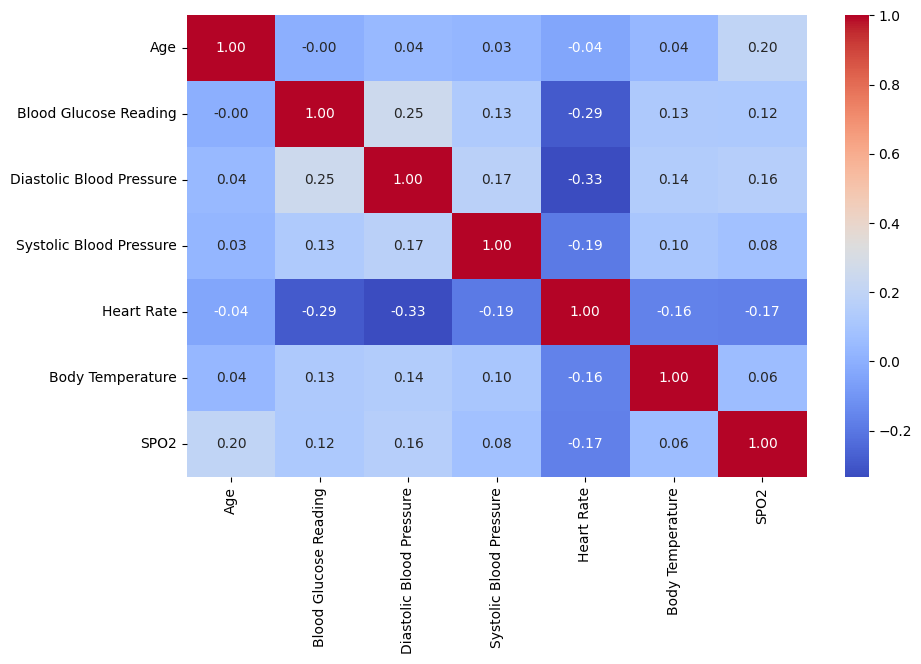

In [514]:
plt.figure(figsize=(10, 6))

corr_matrix = train_eda[num_col].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

To avoid test-set leakage, the train-test split was performed before statistical EDA. Target-based EDA methods such as Chi-square test, Cramer’s V, Welch’s t-test, Cohen’s d, and correlation analysis were performed only on the training data. The test set was kept unseen and used only once for final model evaluation.

### preprocessing pipeline

In [515]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_col),
        ('bin', binary_transformer, binary_cols)
    ]
)

### Train multiple models using CV

In [516]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight

models = {
    'LogisticRegression': LogisticRegression( max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier( n_estimators=200, random_state=42, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200 , random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200,random_state=42),
    'SVC': SVC( probability=True, class_weight='balanced', random_state=42)
}

no_class_weight_support = ['GradientBoosting', 'AdaBoost']

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    params = None
    if name in no_class_weight_support:
        sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
        params = {'classifier__sample_weight': sample_weight}

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        params=params
    )

    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Balanced_Accuracy': scores['test_balanced_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1_Score': scores['test_f1'].mean(),
        'ROC_AUC': scores['test_roc_auc'].mean(),
        'PR_AUC': scores['test_pr_auc'].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by='PR_AUC',
    ascending=False
)

cv_results_df

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
2,GradientBoosting,0.998208,0.984705,0.999418,0.998754,0.999086,0.999830,0.999997
1,RandomForest,0.996823,0.920171,0.996853,0.999917,0.998383,0.999781,0.999995
3,AdaBoost,0.997067,0.975823,0.999086,0.997923,0.998504,0.999595,0.999992
4,SVC,0.967905,0.938272,0.998118,0.969098,0.983391,0.990002,0.999794
0,LogisticRegression,0.876018,0.848366,0.995963,0.877140,0.932716,0.942676,0.998487


### Gradient Boosting best model 

### Hyperparameter tuning using (GridSearchCV)

In [517]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

no_class_weight_support = ['GradientBoosting', 'AdaBoost']

param_grids = {
    'LogisticRegression': {'classifier__C': [0.01, 0.1, 1, 10]},
    'RandomForest': {'classifier__n_estimators': [100, 200, 300],
                      'classifier__max_depth': [None, 5, 10]},
    'GradientBoosting': {'classifier__n_estimators': [100, 200],
                          'classifier__learning_rate': [0.05, 0.1],
                          'classifier__max_depth': [2, 3]},
    'AdaBoost': {'classifier__n_estimators': [100, 200, 300],
                 'classifier__learning_rate': [0.5, 1.0]},
    'SVC': {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['rbf', 'linear']},
}

winner_name = 'GradientBoosting'

winner_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ))
])

grid = GridSearchCV(
    winner_pipe,
    param_grids[winner_name],
    cv=cv,
    scoring='average_precision',
    n_jobs=-1
)

fit_params = {}
if winner_name in no_class_weight_support:
    sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
    fit_params = {'classifier__sample_weight': sample_weight}

grid.fit(X_train, y_train, **fit_params)  

print("Best params:", grid.best_params_)
print("Best CV PR-AUC:", grid.best_score_)

best_model = grid.best_estimator_

Best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Best CV PR-AUC: 0.9999966448401114


### Final Model Evaluation

In [518]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=['Non-Diabetic', 'Diabetic']
))

Accuracy: 0.9993485342019544
Balanced Accuracy: 0.9996677740863787
ROC AUC: 0.9999944629014396
PR AUC: 0.9999998896625992

Confusion Matrix:
[[  60    0]
 [   2 3008]]

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.97      1.00      0.98        60
    Diabetic       1.00      1.00      1.00      3010

    accuracy                           1.00      3070
   macro avg       0.98      1.00      0.99      3070
weighted avg       1.00      1.00      1.00      3070



### Confusion Matrix

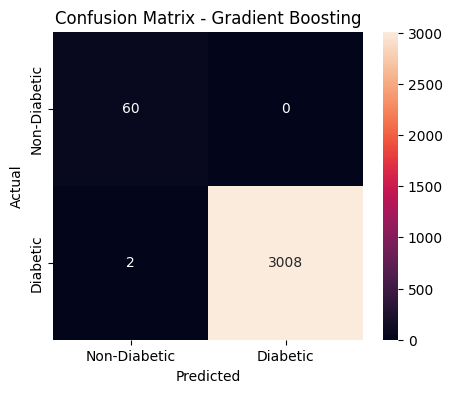

In [519]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

60  = Correctly predicted Non-Diabetic
0  = Actual Non-Diabetic but predicted Diabetic
2  = Actual Diabetic but predicted Non-Diabetic
3009 = Correctly predicted Diabetic

### ROC and Precision Recall Curve

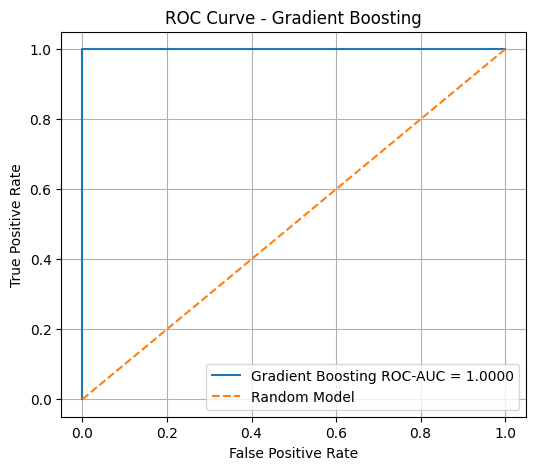

In [520]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probability for class 1 = Diabetic
y_proba = best_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Gradient Boosting ROC-AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Model')

plt.title('ROC Curve - Gradient Boosting')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

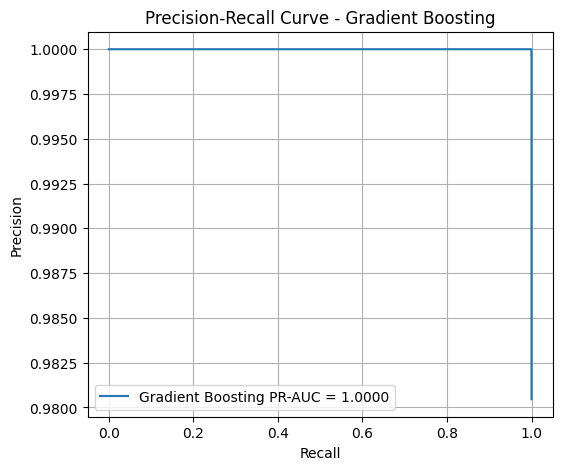

In [521]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Predicted probability for class 1 = Diabetic
y_proba = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)


pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Gradient Boosting PR-AUC = {pr_auc:.4f}')

plt.title('Precision-Recall Curve - Gradient Boosting')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()

The Precision-Recall curve was also plotted because the dataset is highly imbalanced. PR-AUC provides a better view of model performance when one class dominates the dataset.

### Features Importance

In [522]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importances = best_model.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(30)

,Feature,Importance
5,num__Body Temperature,0.394720
1,num__Blood Glucose Reading,0.239806
3,num__Systolic Blood Pressure,0.131746
0,num__Age,0.073738
6,num__SPO2,0.038901
15,cat__Age_Group_Adult,0.034355
22,bin__Sweating (Y/N),0.033993
23,bin__Shivering (Y/N),0.017483
4,num__Heart Rate,0.009976
8,num__MAP,0.008586


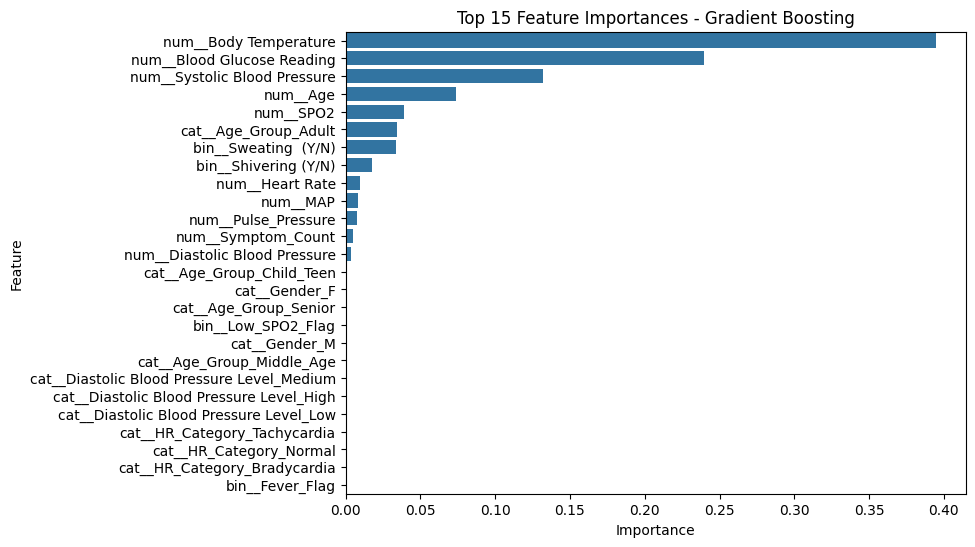

In [523]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(30)
)

plt.title('Top 15 Feature Importances - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [524]:
import joblib

joblib.dump(best_model, 'diabetes_non_diabetes_pipeline.pkl')
print("Saved pipeline: diabetes_non_diabetes_pipeline.pkl")

Saved pipeline: diabetes_non_diabetes_pipeline.pkl


In [525]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0]

print("Sample Data:")
display(sample)

print("Actual value:", y_test.iloc[0])
print("Predicted value:", prediction)

print("Probability of Non-Diabetic:", probability[0])
print("Probability of Diabetic:", probability[1])

if prediction == 1:
    print("Final Prediction: Diabetic")
else:
    print("Final Prediction: Non-Diabetic")

Sample Data:


,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Pulse_Pressure,MAP,Symptom_Count,Gender,Diastolic Blood Pressure Level,Age_Group,HR_Category,Sweating (Y/N),Shivering (Y/N),Low_SPO2_Flag,Fever_Flag
5627,9.0,76.0,81.0,113.0,93.0,96.056328,98.0,32.0,91.666667,0,M,High,Child_Teen,Normal,0,0,0,0


Actual value: 1
Predicted value: 1
Probability of Non-Diabetic: 0.0002164321461080032
Probability of Diabetic: 0.999783567853892
Final Prediction: Diabetic


In [530]:
y.value_counts()

Diabetic_Target
1    15048
0      298
Name: count, dtype: int64

### The model correctly classified all 60 Non-Diabetic samples in the test set. However, because the minority-class test size was small, this result should be interpreted cautiously and validated with more Non-Diabetic cases.